In [ ]:
!pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest

import shap
import warnings
warnings.filterwarnings("ignore")

In [ ]:
FILE_PATH = "/content/human_vital_signs_dataset_2024.csv"

In [ ]:
print("Loading dataset...")
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
df.head()

Loading dataset...
Dataset shape: (200020, 17)


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [ ]:
data = df.copy()
data["Timestamp"] = pd.to_datetime(data["Timestamp"])

NON_NUMERIC_COLS = ["Patient ID", "Timestamp", "Gender", "Risk Category"]
data_numeric = data.drop(columns=NON_NUMERIC_COLS)

data_numeric.head()


,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
0,60,12,36.861707,95.702046,124,86,37,91.541618,1.679351,0.121033,38,32.459031,98.666667
1,63,18,36.511633,96.689413,126,84,77,50.704921,1.992546,0.117062,42,12.771246,98.000000
2,63,15,37.052049,98.508265,131,78,68,90.316760,1.770228,0.053200,53,28.821069,95.666667
3,99,16,36.654748,95.011801,118,72,41,96.006188,1.833629,0.064475,46,28.554611,87.333333
4,69,16,36.975098,98.623792,138,76,25,56.020006,1.866419,0.118484,62,16.081438,96.666667


In [ ]:
scaler = MinMaxScaler()

scaled_df = pd.DataFrame(
    scaler.fit_transform(data_numeric),
    columns=data_numeric.columns
)

scaled_df.head()

,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
0,0.000000,0.000000,0.574473,0.140409,0.482759,0.842105,0.267606,0.830836,0.358704,0.710335,0.354167,0.626066,0.686567
1,0.076923,0.857143,0.341088,0.337884,0.551724,0.736842,0.830986,0.014095,0.985098,0.670621,0.437500,0.008323,0.656716
2,0.076923,0.428571,0.701369,0.701658,0.724138,0.421053,0.704225,0.806338,0.540458,0.031997,0.666667,0.511918,0.552239
3,1.000000,0.571429,0.436499,0.002359,0.275862,0.105263,0.323944,0.920128,0.667262,0.144746,0.520833,0.503558,0.179104
4,0.230769,0.571429,0.650068,0.724763,0.965517,0.315789,0.098592,0.120398,0.732842,0.684848,0.854167,0.112187,0.597015


In [ ]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

model.fit(scaled_df)

df["anomaly"] = model.predict(scaled_df)
df["anomaly_score"] = model.decision_function(scaled_df)

df["anomaly"].value_counts()

,count
anomaly,
1,190019
-1,10001


In [ ]:
total = len(df)
anomalies = (df["anomaly"] == -1).sum()

print("Total Records:", total)
print("Anomalies Detected:", anomalies)
print(f"Anomaly Percentage: {anomalies/total*100:.2f}%")

Total Records: 200020
Anomalies Detected: 10001
Anomaly Percentage: 5.00%


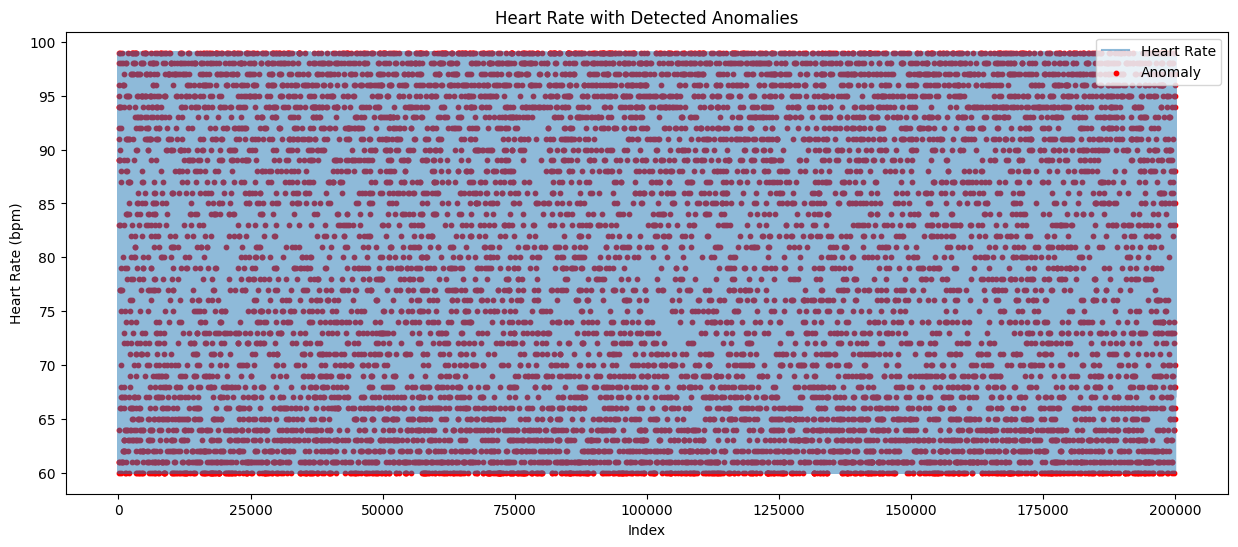

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(df["Heart Rate"], label="Heart Rate", alpha=0.5)
plt.scatter(
    df.index[df["anomaly"] == -1],
    df.loc[df["anomaly"] == -1, "Heart Rate"],
    color="red",
    s=10,
    label="Anomaly"
)

plt.title("Heart Rate with Detected Anomalies")
plt.xlabel("Index")
plt.ylabel("Heart Rate (bpm)")
plt.legend()
plt.show()

In [ ]:
patient_anomaly_count = (
    df[df["anomaly"] == -1]
    .groupby("Patient ID")
    .size()
    .sort_values(ascending=False)
)

patient_anomaly_count.head(10)

,0
Patient ID,
200012,1
199761,1
199747,1
199739,1
199724,1
199721,1
199705,1
199655,1
199646,1


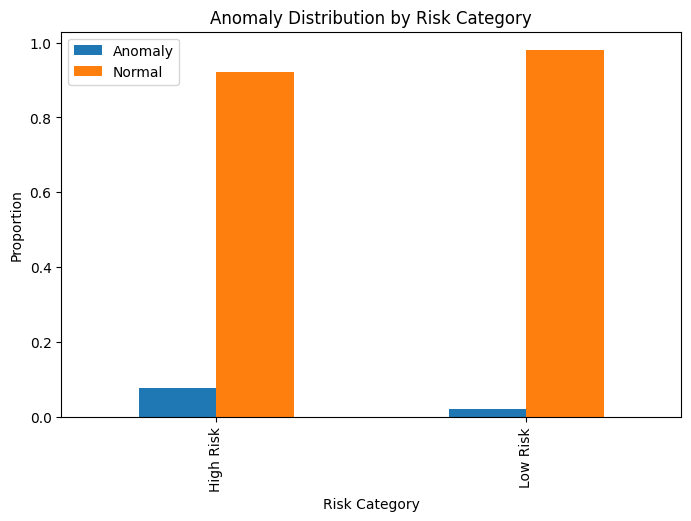

In [ ]:
risk_analysis = pd.crosstab(
    df["Risk Category"],
    df["anomaly"],
    normalize="index"
)
risk_analysis.columns = ["Anomaly", "Normal"]

risk_analysis.plot(kind="bar", figsize=(8,5))
plt.title("Anomaly Distribution by Risk Category")
plt.ylabel("Proportion")
plt.show()

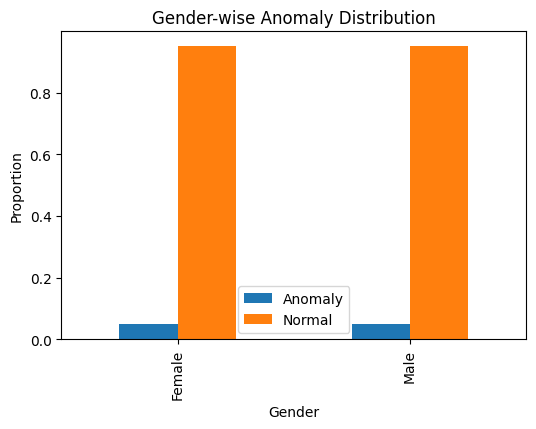

In [ ]:
gender_analysis = pd.crosstab(
    df["Gender"],
    df["anomaly"],
    normalize="index"
)
gender_analysis.columns = ["Anomaly", "Normal"]

gender_analysis.plot(kind="bar", figsize=(6,4))
plt.title("Gender-wise Anomaly Distribution")
plt.ylabel("Proportion")
plt.show()

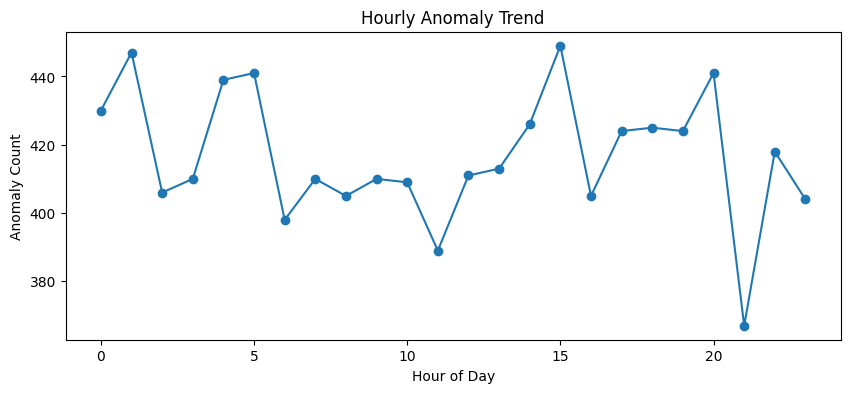

In [ ]:
df["hour"] = data["Timestamp"].dt.hour

hourly_anomalies = (
    df[df["anomaly"] == -1]
    .groupby("hour")
    .size()
)

hourly_anomalies.plot(marker="o", figsize=(10,4))
plt.title("Hourly Anomaly Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Anomaly Count")
plt.show()

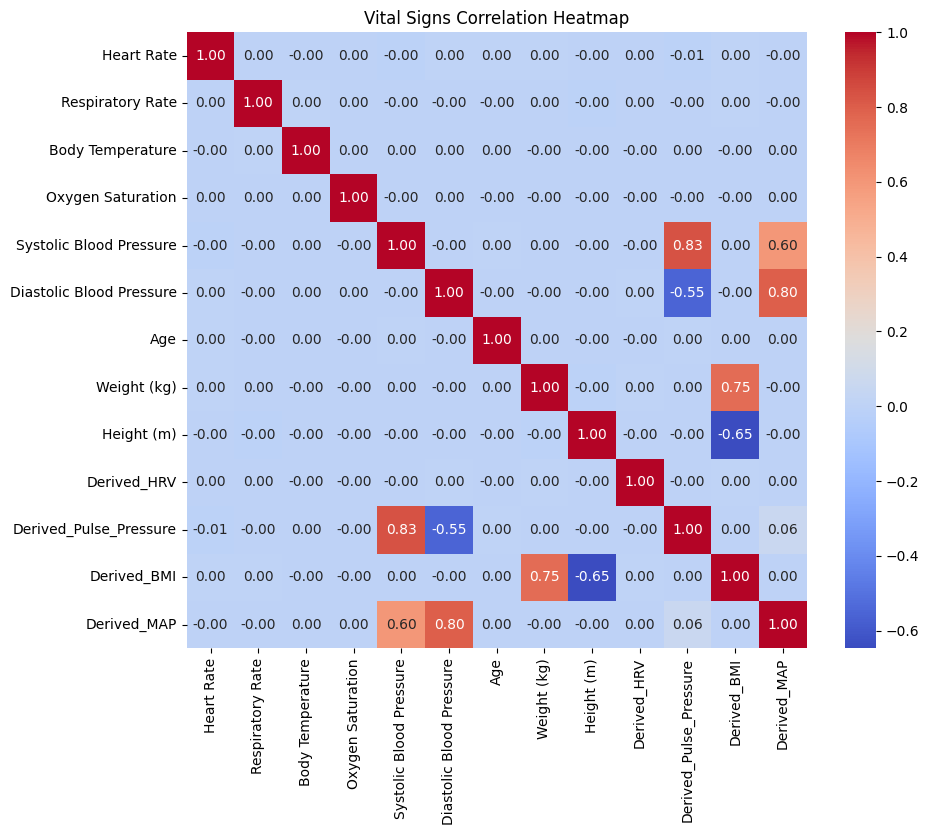

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    data_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Vital Signs Correlation Heatmap")
plt.show()

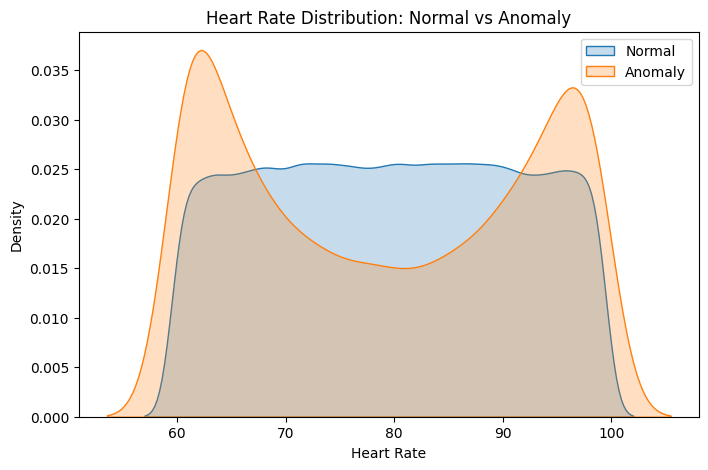

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df[df["anomaly"] == 1]["Heart Rate"], label="Normal", fill=True)
sns.kdeplot(df[df["anomaly"] == -1]["Heart Rate"], label="Anomaly", fill=True)

plt.title("Heart Rate Distribution: Normal vs Anomaly")
plt.legend()
plt.show()

Computing SHAP values...


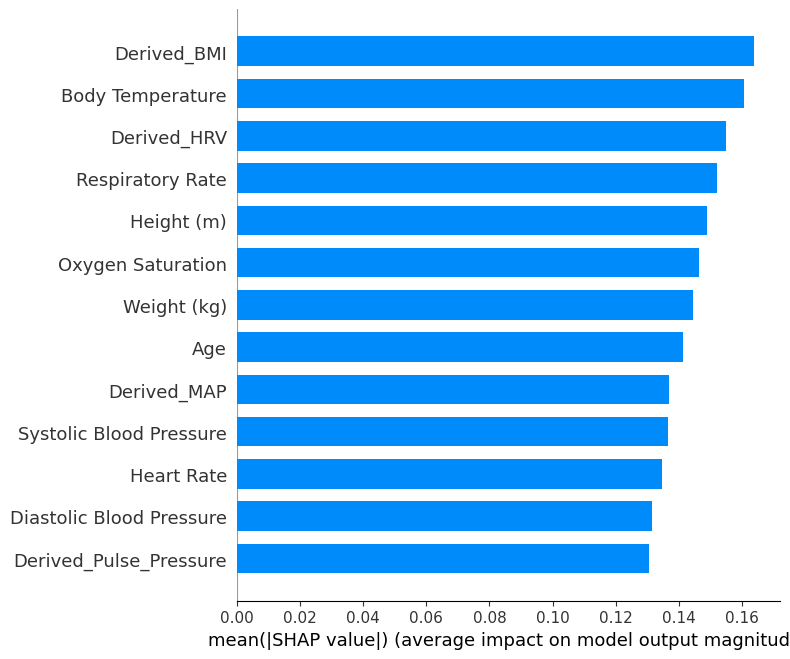

In [ ]:
print("Computing SHAP values...")

sample_df = scaled_df.sample(
    min(3000, len(scaled_df)),
    random_state=42
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_df)

shap.summary_plot(shap_values, sample_df, plot_type="bar")

In [ ]:
shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=sample_df.columns
)

mean_shap = shap_df.mean().sort_values(ascending=False)
mean_shap.head(10)

,0
Derived_BMI,0.163820
Body Temperature,0.160675
Derived_HRV,0.154942
Respiratory Rate,0.152157
Height (m),0.148817
Oxygen Saturation,0.146267
Weight (kg),0.144549
Age,0.141313
Derived_MAP,0.136945
Systolic Blood Pressure,0.136646


In [ ]:
severe_cases = df.sort_values("anomaly_score").head(10)
severe_cases[["Patient ID", "Timestamp", "anomaly_score"]]

,Patient ID,Timestamp,anomaly_score
79480,79481,2024-05-25 17:13:45.932887,-0.073066
101154,101155,2024-05-10 15:59:45.991896,-0.071626
31423,31424,2024-06-28 02:10:45.809987,-0.063980
65733,65734,2024-06-04 06:20:45.895875,-0.063567
156658,156659,2024-04-02 02:55:46.131052,-0.061888
8617,8618,2024-07-13 22:16:45.753846,-0.060103
155863,155864,2024-04-02 16:10:46.128052,-0.059689
167416,167417,2024-03-25 15:37:46.161932,-0.058929
194849,194850,2024-03-06 14:24:46.235947,-0.058361
139187,139188,2024-04-14 06:06:46.085914,-0.057350
